## CS5004 E-tivity 3

Name: Sean Noonan

StudentId: 2300159

Tasks 1 - 3 run to completion. For task 1 attached images required.

Dor DQN used: https://github.com/ageron/handson-ml3/blob/main/18_reinforcement_learning.ipynb

# Task 1:
Windy grid learning


In [19]:
# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
import random

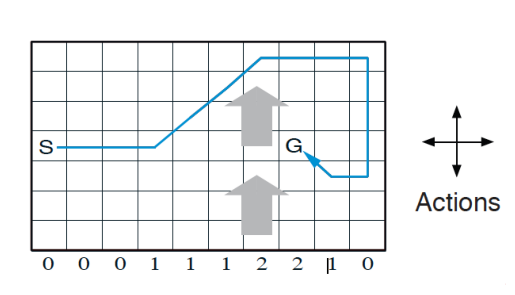

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

# Load the image
image_path = "windy_gridworld.png"
image = Image.open(image_path)

# Display the image
plt.imshow(image)
plt.axis("off")  # Hide axis labels
plt.show()


Person starts at S, moves at random until they reach G. There is a wind that deflects their movement given for each column by (0,0,0,1,1,1,2,2,1,0). Each move has a reward of -1.

We want to find an optimal policy from moving to start to goal

In [21]:
# Follow Q-learning algorithm

# Gridworld dimensions
# 7x10 gid
rows = 7
cols = 10
# We begin midway down the first column and want to finish
start = (3, 0)
goal = (3, 7)

# Wind strength per column
wind = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]

# Actions: Up, Down, Left, Right
actions = [(0, 1), (0, -1), (-1, 0), (1, 0)]  # Right, Left, Up, Down

In [22]:
# Set up
episodes = 200 #  At my discretion
epsilon = 0.1 # deviation from greedy
alpha = 0.5   # Learning rate
gamma = 1.0   # reward difference decay rate

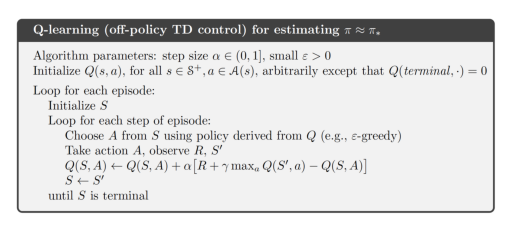

In [23]:
# Load the image
image_path1 = "Qlearning_algorithm.png"  # Replace with your image path
image1 = Image.open(image_path1)

# Display the image
plt.imshow(image1)
plt.axis("off")  # Hide axis labels
plt.show()

In [24]:
# Function to choose an action using epsilon-greedy policy - step in above algorithm
def choose_At(state):
    if random.uniform(0, 1) < epsilon:
        return random.choice(actions)  # deviate epsilon percent of time - exploration
    else:
        return max(Qtable[state], key=Qtable[state].get)  # Take max value - greedy policy to take best it has seen

In [25]:
# Function to take action A and observe new state S'= St1, reward Rt
def take_At(St, At):
    row, col = St
    d_row, d_col = At

    # Apply action
    new_row = min(max(row + d_row - wind[col], 0), rows - 1)
    new_col = min(max(col + d_col, 0), cols - 1)

    # Reward is always -1 per move
    Rt = -1

    return (new_row, new_col), Rt

In [26]:
# Loop for each episode
E_Gt = []

paths = []  # Store routes

# Q table creation -  Set all to zero
Qtable = {}
for row in range(rows):
    for col in range(cols):
        Qtable[(row, col)] = {action: 0 for action in actions}

for episode in range(episodes):
    St = start
    Gt = 0
    path = [St]  # Lets track the agent's path, initialize it at start point

    while St != goal:
        At = choose_At(St)
        St1, Rt = take_At(St, At)
        Gt += Rt

        # Q-learning update equation
        best_At1 = max(Qtable[St1], key=Qtable[St1].get)
        Qtable[St][At] += alpha * (Rt + gamma * Qtable[St1][best_At1] - Qtable[St][At])

        # Update state to new state
        St = St1
        path.append(St)  # Append new state

    E_Gt.append(Gt)
    # Store path for visualization (only for last episode)
    # if episode == episodes - 1:
    paths.append(path)

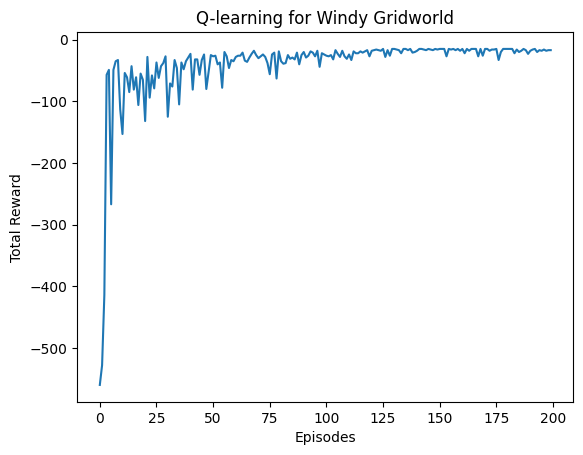

In [27]:
# Plotting learning curve
plt.plot(E_Gt)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning for Windy Gridworld")
plt.show()

In [28]:
# Print last 10 values
print(E_Gt[-10:])

[-18, -16, -15, -20, -17, -18, -16, -18, -17, -17]


We can see that the total reward converges to around -15. This is 15 moves.

It takes about 100 episodes to get to converge to this optimal route policy in a steady mannor.

Lets take a look at the optimal path

In [29]:
max_reward_index = E_Gt.index(max(E_Gt))  # Get index of episode with max reward
print(max_reward_index)
optimal_path = paths[max_reward_index]  # Path corresponding to max reward


125


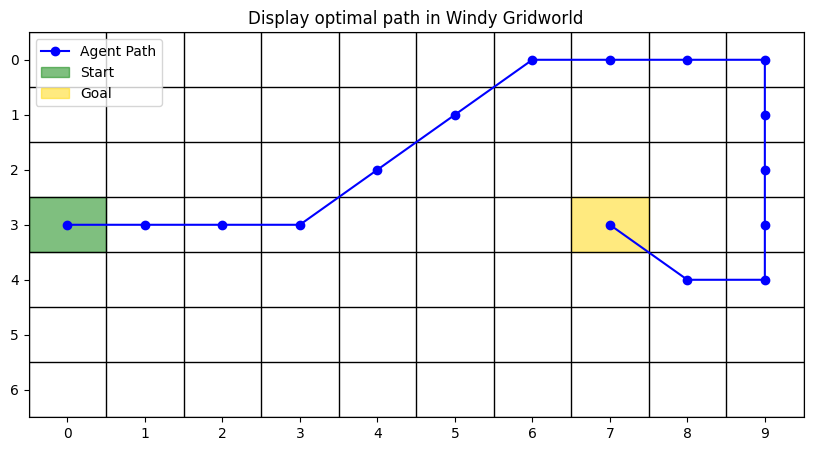

In [30]:
# Function to plot the path correctly
def plot_path(grid_size, path, title="Final Agent Path in Windy Gridworld"):
    fig, ax = plt.subplots(figsize=(10, 5))

    # Draw grid
    for i in range(grid_size[0] + 1):
        ax.plot([-0.5, grid_size[1] - 0.5], [i - 0.5, i - 0.5], "k", lw=1)
    for j in range(grid_size[1] + 1):
        ax.plot([j - 0.5, j - 0.5], [-0.5, grid_size[0] - 0.5], "k", lw=1)

    # Plot the path ensuring it starts at START and ends at GOAL
    path_x, path_y = zip(*path)
    ax.plot(path_y, path_x, marker="o", color="blue", markersize=6, label="Agent Path", linestyle="-")

    # Mark start and goal
    ax.add_patch(plt.Rectangle((start[1] - 0.5, start[0] - 0.5), 1, 1, color="green", alpha=0.5, label="Start"))
    ax.add_patch(plt.Rectangle((goal[1] - 0.5, goal[0] - 0.5), 1, 1, color="gold", alpha=0.5, label="Goal"))

    # Adjust plot limits
    ax.set_xlim(-0.5, grid_size[1] - 0.5)
    ax.set_ylim(grid_size[0] - 0.5, -0.5)  # Invert y-axis for correct display
    ax.set_xticks(range(grid_size[1]))
    ax.set_yticks(range(grid_size[0]))
    ax.set_xticklabels(range(grid_size[1]))
    ax.set_yticklabels(range(grid_size[0]))
    ax.legend()
    ax.set_title(title)

    plt.show()

# Plot path for the last episode
plot_path((rows, cols), optimal_path, "Display optimal path in Windy Gridworld")

We can see the 15 optimal steps taken to get to the Goal.

**Lets try this with Sarsa**

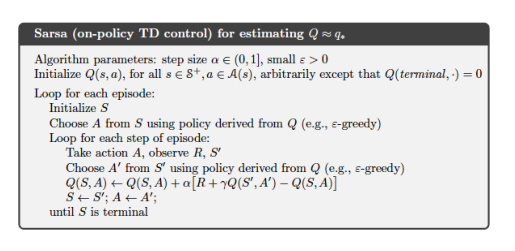

In [31]:
# Load the image
image_path2 = "sarsa.png"  # Replace with your image path
image2 = Image.open(image_path2)

# Display the image
plt.imshow(image2)
plt.axis("off")  # Hide axis labels
plt.show()

In [32]:
# Set up
episodes = 200 #  At my discretion
epsilon = 0.1 # deviation from greedy
alpha = 0.1   # Learning rate
gamma = 0.   # reward difference decay rate

In [33]:
E_GtS = []  # Store total rewards per episode
pathsS = []  # Store routes

# Q table creation - Set all values to zero initially
QtableS = {}
for row in range(rows):
    for col in range(cols):
        QtableS[(row, col)] = {action: 0 for action in actions}

for episode in range(episodes):
    St = start
    At = choose_At(St)  # Choose first action (on-policy)
    Gt = 0
    path = [St]  # Track agent's path, initialize at start point

    while St != goal:
        St1, Rt = take_At(St, At)  # Take step, observe new state and reward
        At1 = choose_At(St1)  # Choose A_{t+1} using epsilon-greedy

        # SARSA update equation
        Qtable[St][At] += alpha * (Rt + gamma * Qtable[St1][At1] - Qtable[St][At])

        # Update for next iteration
        St, At = St1, At1
        Gt += Rt
        path.append(St)  # Append new state

    E_GtS.append(Gt)  # Store total episode reward
    pathsS.append(path)  # Store path for visualization



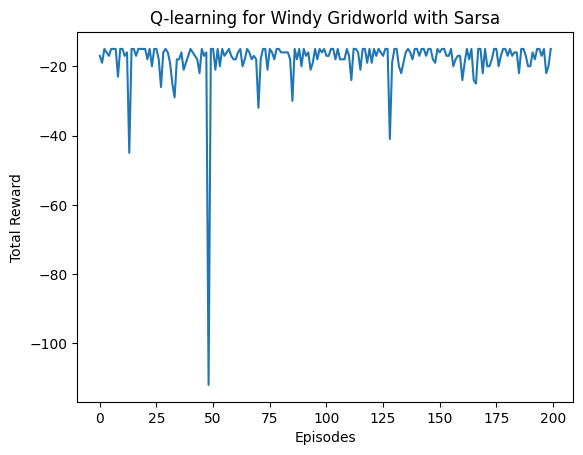

In [34]:
# Plotting learning curve
plt.plot(E_GtS)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-learning for Windy Gridworld with Sarsa")
plt.show()

This is extremely unstable.

Sarsa is more conservative than Q learning. Q learning takes risks by asusming the best possible action.

It takes longer to converge but at least we know we will get there.

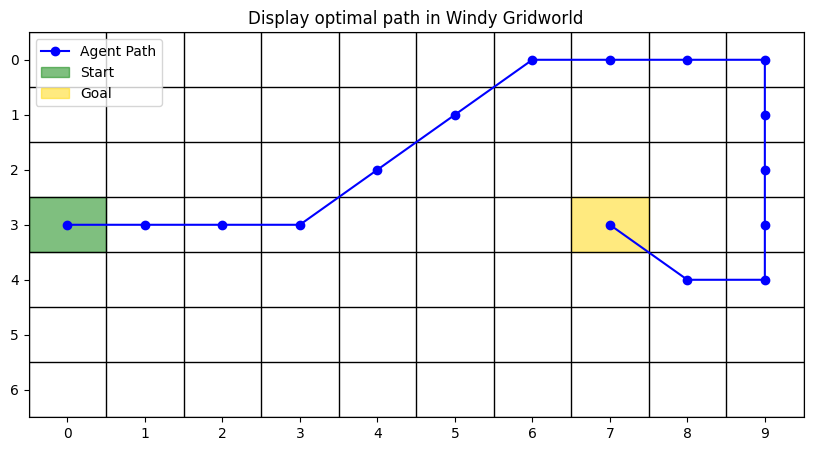

In [35]:
max_reward_indexS = E_GtS.index(max(E_GtS))  # Get index of episode with max reward

optimal_pathS = paths[max_reward_index]  # Path corresponding to max reward
# Plot path for the last episode
plot_path((rows, cols), optimal_pathS, "Display optimal path in Windy Gridworld")

Sarsa gets there quicker but is not stable

## Reflection

In this Tabular Q-learning problem an epsilon greedy approach was used to find the optimal path in a gridworld problem that had a wind factor.

This was done for TD and Sarsa. Sarsa does not converge well but this reach closer to the final optimal path quicker.

Upon my peers comments I found I had been displaying the final path which is not always the optimal one. This was updated.

#### Task 2

***CS5004 DQN Lunar landing Classic Control AY 24/25***


In this task I will look at classic control for lunar landing

This project requires Python 3.10 or above:

In [1]:
import sys
assert sys.version_info >= (3, 10)

from packaging import version
import tensorflow as tf
assert version.parse(tf.__version__) >= version.parse("2.8.0")

import matplotlib.animation
import matplotlib.pyplot as plt

In [2]:
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    import os
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

In [3]:
if "google.colab" in sys.modules or "kaggle_secrets" in sys.modules:
    %pip install -q -U gymnasium swig
    %pip install -q -U gymnasium[classic_control,box2d,atari]

import gymnasium as gym

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


And TensorFlow ≥ 2.8:

Define the default font sizes for plots.

In [39]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('animation', html='jshtml')

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "rl"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

Import lunar lander

In [5]:
import gymnasium as gym

# Create the environment
env = gym.make("LunarLander-v3", render_mode="rgb_array")

The LunarLander-v3 environment consists of a spacecraft that must land safely on a designated landing pad. The agent controls the lander by firing thrusters to adjust its position, velocity, and angle. The objective is to land the spacecraft smoothly while minimizing fuel usage and avoiding crashes.

Each observation is a 1D NumPy array composed of 8 floats:

X Position → Horizontal position of the lander.
Y Position → Vertical position of the lander.
X Velocity → Speed of the lander in the horizontal direction.
Y Velocity → Speed of the lander in the vertical direction.
Angle → Orientation of the lander (0 = perfectly upright).
Angular Velocity → How fast the lander is rotating.
Left Leg Contact → 1 if the left leg touches the ground, else 0.
Right Leg Contact → 1 if the right leg touches the ground, else 0.
There are four possible actions:

0 → Do nothing (no thrust).
1 → Fire left thruster (push right).
2 → Fire main thruster (push up).
3 → Fire right thruster (push left).
The agent must control the thrusters to land safely on the landing pad while minimizing fuel consumption and avoiding crashes. The environment provides rewards for smooth landings and penalties for crashes or excessive fuel usage.

From an RL point of view:

The agent is the spaceship.

The environment is the lunar surface.

The state includes position, velocity, and angle.

The actions include firing left, right, or no thrusters.

The reward is based on how well the agent lands.

The lunar lander has a lot of cases for reward. this will make it easier to train. Sparse reward problems like the mountain car can require an extortionate amount of training and stability tuning in order to achieve good results.

In [42]:
spec = gym.spec("LunarLander-v3")
print(spec)

EnvSpec(id='LunarLander-v3', entry_point='gymnasium.envs.box2d.lunar_lander:LunarLander', reward_threshold=200, nondeterministic=False, max_episode_steps=1000, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='LunarLander', version=3, additional_wrappers=(), vector_entry_point=None)


In [43]:
# Reset environment and ensure reproducibility
obs, info = env.reset(seed=42)

# Print initial state
print("Observation:", obs)
print("Info:", info)


Observation: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]
Info: {}


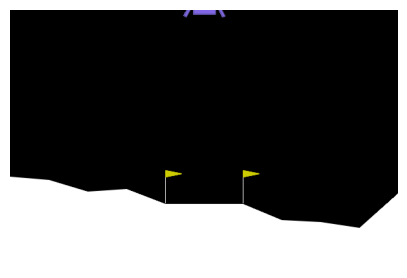

In [44]:
# extra code – creates a little function to render and plot an environment

def plot_environment(env, figsize=(5, 4)):
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img

plot_environment(env)
plt.show()

We are tryign to land within the flags

In [45]:
env.action_space

action = 1  # accelerate right
obs, reward, done, truncated, info = env.step(action)
obs

array([ 0.00449829,  1.4247646 ,  0.22032492,  0.294843  , -0.00285054,
       -0.00391279,  0.        ,  0.        ], dtype=float32)

In [46]:
if done or truncated:
    obs, info = env.reset()

# Deep Q-Network

In [47]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU

input_shape = [8]  # LunarLander-v2 has 8 state variables
n_outputs = 4  # == env.action_space.n

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="elu", input_shape=input_shape, kernel_initializer="he_normal"),
    tf.keras.layers.Dense(32, activation="elu", kernel_initializer="he_normal"),
    tf.keras.layers.Dense(n_outputs)
])

def epsilon_greedy_policy(state, epsilon=0):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)  # random action
    else:
        Q_values = model.predict(state[np.newaxis], verbose=0)[0]
        return Q_values.argmax()  # optimal action according to the DQN

In [48]:
#  Create the Target Model (Copy of Main Model)
target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())  # Copy initial weights


In [49]:
# extra code – A basic circular buffer implementation

from collections import deque

replay_buffer = deque(maxlen=2000)

def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    return [
        np.array([experience[field_index] for experience in batch])
          for field_index in range(6)
    ]  # [states, actions, rewards, next_states, dones, truncateds]

Now we can create a function that will use the DQN to play one step, and record its experience in the replay buffer:

In [50]:
def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

Lastly, let's create a function that will sample some experiences from the replay buffer and perform a training step:

In [51]:
import numpy as np

In [52]:
# extra code – for reproducibility, and to generate the next figure
env.reset(seed=42)
np.random.seed(42)
tf.random.set_seed(42)
rewards = []
best_score = 0

In [53]:
batch_size = 64
discount_factor = 0.95
optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-3)
loss_fn = tf.keras.losses.mean_squared_error

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones, truncateds = experiences
    next_Q_values = model.predict(next_states, verbose=0)
    # next_Q_values = target_model.predict(next_states, verbose=0) # Double DQN
    max_next_Q_values = next_Q_values.max(axis=1)
    runs = 1.0 - (dones | truncateds)  # episode is not done or truncated
    runs = 1.0 - dones  # No need for truncateds
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = target_Q_values.reshape(-1, 1)
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

In [54]:
def is_landed(state):
    return state[6] == 1 and state[7] == 1  # Both legs touching

And now, let's train the model!

In [55]:
q_values_log = []
rewards = []

for episode in range(300):
    obs, info = env.reset()
    total_reward=0
    epsilon = 0.01 + (1.0 - 0.01) * np.exp(-episode / 600)
    epsilon = max(0.01, 1.0 - episode / 1000)
    # epsilon = 0.9
    for step in range(4000): # 4000 steps is never reached
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        total_reward += reward  # Accumulate episode rewards
        if done or truncated:
            break
    # Store Q-values for analysis
    q_values = model.predict(obs[np.newaxis], verbose=0)[0]  # Get Q-values for current state
    q_values_log.append(q_values)

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, Reward: {total_reward}, eps: {epsilon:.3f}",
          end="")
    # rewards.append(step)
    rewards.append(total_reward)
    if total_reward >= best_score:
        best_weights = model.get_weights()
        best_score = total_reward
        print(f"\n New High Score: {best_score:.2f}")

    if episode > 50:
        training_step(batch_size)

    # Update Target Network every 5 episodes
    if episode % 50 == 0:
        target_model.set_weights(model.get_weights())

model.set_weights(best_weights)  # extra code – restores the best model weights

Episode: 52, Steps: 65, Reward: -103.23983331825453, eps: 0.949

Episode: 127, Steps: 88, Reward: 6.039560812607192, eps: 0.874
 New High Score: 6.04
Episode: 300, Steps: 107, Reward: -270.7897058988756, eps: 0.701

Epsilon decides how much exploration versus exploitation

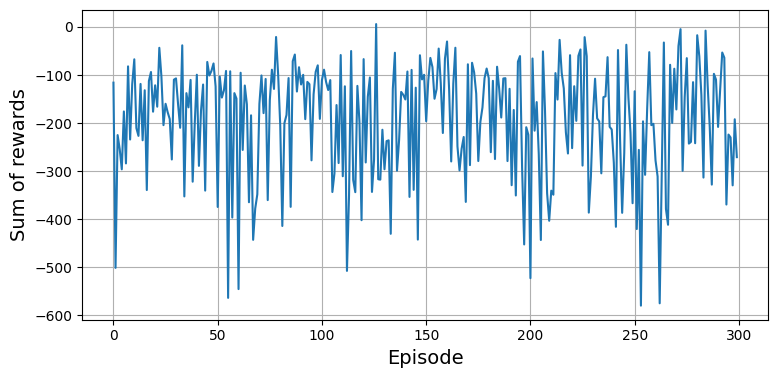

In [56]:
# extra code – this cell generates and saves Figure 18–10
plt.figure(figsize=(8, 4))
plt.plot(rewards)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
save_fig("dqn_ll_rewards_plot")
plt.show()

The model seems to get worse which suggests algorithm has some issues. It might be that it needs more time. It is not very stable at all.

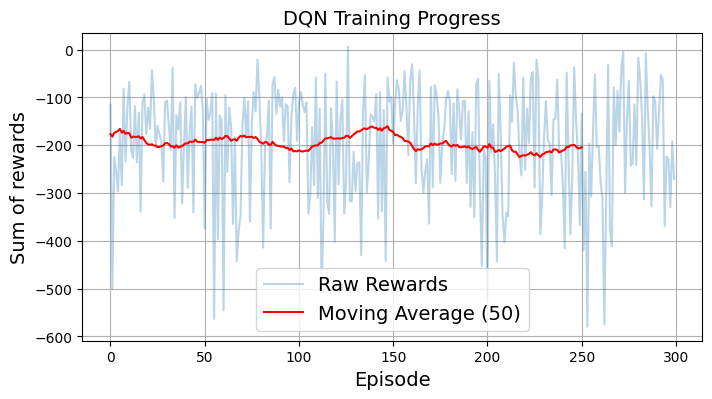

In [57]:
# Define moving average function
def moving_average(values, window_size=50):
    return np.convolve(values, np.ones(window_size)/window_size, mode='valid')

# Generate reward plot with moving average
plt.figure(figsize=(8, 4))
plt.plot(rewards, label="Raw Rewards", alpha=0.3)  # Original noisy rewards
plt.plot(moving_average(rewards, window_size=50), label="Moving Average (50)", color="red")
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.legend()
plt.grid(True)
plt.title("DQN Training Progress")

# Show plot
plt.show()


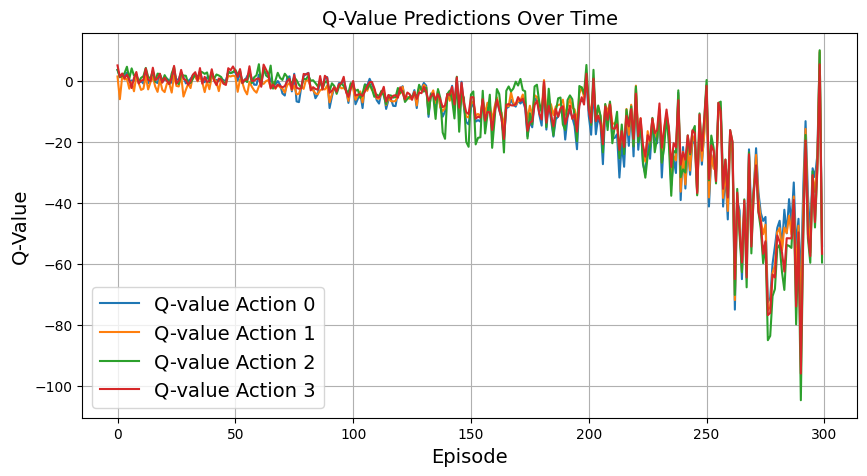

In [58]:
# Convert Q-values to NumPy array for plotting
q_values_log = np.array(q_values_log)

plt.figure(figsize=(10, 5))

# Plot Q-values for each action over episodes
for action in range(n_outputs):
    plt.plot(q_values_log[:, action], label=f"Q-value Action {action}")

plt.xlabel("Episode")
plt.ylabel("Q-Value")
plt.title("Q-Value Predictions Over Time")
plt.legend()
plt.grid()
plt.show()


In the early episodes the Q-values are stable and close to zero, as agent is still exploring.

They then decrease as agent learns actions resulting i lareg negative rewards.

Double DQN - using target network

In [59]:
def training_step_double_dqn(batch_size):
    """Performs experience replay and updates Q-values using Double DQN."""

    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones, truncateds = experiences

    # Double DQN: Use Online Network to Select Best Action in Next State
    best_actions = np.argmax(model.predict(next_states, verbose=0), axis=1)  # Online selects action

    # Double DQN: Use Target Network to Estimate Q-Value for Selected Action
    next_Q_values = target_model.predict(next_states, verbose=0)  # Target network gives Q-values
    max_next_Q_values = next_Q_values[np.arange(batch_size), best_actions]  # Get Q-value of chosen action

    # Only use future rewards if episode is not done
    runs = 1.0 - dones
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = target_Q_values.reshape(-1, 1)

    # Compute loss and apply gradients
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)  # Get Q-values from online network
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))



In [ ]:
q_values_log = []
rewardsD = []
frames = []  # Store frames for animation

episode_count = 450

for episode in range(450):
    obs, info = env.reset()
    total_reward=0
    # epsilon = 0.01 + (1.0 - 0.01) * np.exp(-episode / 600)
    # epsilon = 0.5
    epsilon = max(0.01, 1.0 - episode / (episode_count+100))
    for step in range(4000): # 4000 steps is never reached
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        total_reward += reward  # Accumulate episode rewards

        # Capture frame for animation
        frame = env.render()
        frames.append(frame)

        if done or truncated:
            break
    # Store Q-values for analysis
    q_values = model.predict(obs[np.newaxis], verbose=0)[0]  # Get Q-values for current state
    q_values_log.append(q_values)

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, Reward: {total_reward}, eps: {epsilon:.3f}",
          end="")
    # rewards.append(step)
    rewardsD.append(total_reward)

    if total_reward >= best_score:
        best_weights = model.get_weights()
        best_score = total_reward
        print(f"\n New High Score: {best_score:.2f}")

    if episode > 50:
        training_step_double_dqn(batch_size)

    # Update Target Network every 50 episodes
    if episode % 40 == 0:
        target_model.set_weights(model.get_weights())

model.set_weights(best_weights)  # extra code – restores the best model weights

Episode: 6, Steps: 78, Reward: 18.7114765635677, eps: 0.991
 New High Score: 18.71
Episode: 158, Steps: 123, Reward: -122.76473885826721, eps: 0.715

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def plot_animation(frames, skip=4, repeat=False, interval=40):

    frames = frames[::skip]  #  Skip frames to reduce load. -ease runtime

    fig, ax = plt.subplots()
    patch = ax.imshow(frames[0], cmap='gray', interpolation='none')
    ax.axis('off')

    def update_scene(num, frames, patch):
        patch.set_data(frames[num])
        return patch,

    anim = animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)

    plt.close(fig)  #  Prevent duplicate frame display
    return HTML(anim.to_jshtml())  # Return HTML for Colab playback



In [ ]:
# Display animation
anim = plot_animation(frames, skip=8)
display(anim)  # This Works in Google Colab but takes about 2 mins to run(depending on how many frames you pull)


From watching the frames, it seems the spaceship is crashing a lot.

The ship seems to be taking too many risky and lareg actions. How can we minimise this? Reduce epsilon.

In [ ]:
# extra code – this cell generates and saves Figure 18–10
plt.figure(figsize=(8, 4))
plt.plot(rewardsD)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
save_fig("dqn_dble_ll_rewards_plot")
plt.show()

In [ ]:
# Define moving average function
def moving_average(values, window_size=30):
    return np.convolve(values, np.ones(window_size)/window_size, mode='valid')

# Generate reward plot with moving average
plt.figure(figsize=(8, 4))
plt.plot(rewardsD, label="Raw Rewards", alpha=0.3)  # Original noisy rewards
plt.plot(moving_average(rewardsD, window_size=20), label="Moving Average (20)", color="red")
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.legend()
plt.grid(True)
plt.title("DQN Training Progress")

# Show plot

There is some sign of learning here

##### Lets try a grid search

In [ ]:
import itertools

# Define hyperparameter grid
epsilon_decays = [500, 1000, 2000]  # Controls exploration-exploitation trade-off
batch_sizes = [32, 64]  # Number of experiences per training step
discount_factors = [0.95, 0.99]  # Future reward discounting

# Store results
grid_results = []

# Iterate over all combinations of hyperparameters
for epsilon_decay, batch_size, discount_factor in itertools.product(epsilon_decays, batch_sizes, discount_factors):
    print(f"\n🔍 Testing: epsilon_decay={epsilon_decay}, batch_size={batch_size}, discount_factor={discount_factor}")

    # Reset environment and model
    q_values_log = []
    rewardsD = []
    frames = []
    best_score = -np.inf

    episode_count = 200
    for episode in range(episode_count):
        obs, info = env.reset()
        total_reward = 0
        epsilon = max(0.01, 1.0 - episode / (episode_count + epsilon_decay))

        for step in range(4000):  # 4000 steps is rarely reached
            obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
            total_reward += reward

            # Capture frame for animation (reduce frequency if necessary)
            if episode % 10 == 0:
                frame = env.render()
                frames.append(frame)

            if done or truncated:
                break

        # Store Q-values and rewards
        q_values = model.predict(obs[np.newaxis], verbose=0)[0]
        q_values_log.append(q_values)
        rewardsD.append(total_reward)

        # Track best model weights
        if total_reward >= best_score:
            best_weights = model.get_weights()
            best_score = total_reward
            print(f"\n New High Score: {best_score:.2f}")

        # Train the model after 50 episodes
        if episode > 50:
            training_step_double_dqn(batch_size)

        # Update target network every 40 episodes
        if episode % 40 == 0:
            target_model.set_weights(model.get_weights())

    # Restore best model weights for this hyperparameter setting
    model.set_weights(best_weights)

    # Store results for this hyperparameter combination
    avg_reward = np.mean(rewardsD[-50:])  # Take average over last 50 episodes
    grid_results.append((epsilon_decay, batch_size, discount_factor, avg_reward))

# Identify best hyperparameter combination
best_params = max(grid_results, key=lambda x: x[3])
print(f"\n✅ Best hyperparameters: epsilon_decay={best_params[0]}, batch_size={best_params[1]}, discount_factor={best_params[2]}, Avg Reward={best_params[3]:.2f}")



🔍 Testing: epsilon_decay=500, batch_size=32, discount_factor=0.95

 New High Score: -210.65

 New High Score: -155.37

 New High Score: -126.90

 New High Score: -88.06

 New High Score: -71.67

 New High Score: -52.72

 New High Score: 30.81



🔍 Testing: epsilon_decay=500, batch_size=32, discount_factor=0.99

 New High Score: -300.23

 New High Score: -180.63

 New High Score: -170.52

 New High Score: -94.09

 New High Score: -87.43

 New High Score: -80.72

 New High Score: -61.53

 New High Score: -1.30

 New High Score: 2.47

🔍 Testing: epsilon_decay=500, batch_size=64, discount_factor=0.95

 New High Score: -95.40

 New High Score: 36.15

🔍 Testing: epsilon_decay=500, batch_size=64, discount_factor=0.99

 New High Score: -224.06

 New High Score: -105.66

 New High Score: -69.67

 New High Score: -66.01

 New High Score: -56.37

 New High Score: -13.89

 New High Score: 78.53

🔍 Testing: epsilon_decay=1000, batch_size=32, discount_factor=0.95

 New High Score: -225.33

 New High Score: -122.26

 New High Score: -107.56

 New High Score: -48.75

 New High Score: -25.18

 New High Score: 12.23

 New High Score: 21.42

 New High Score: 53.19

🔍 Testing: epsilon_decay=1000, batch_size=32, discount_factor=0.99

 New High Sc

✅ Best hyperparameters: epsilon_decay=500, batch_size=64, discount_factor=0.99, Avg Reward=-131.42

In [ ]:
# Define hyperparameter grid
epsilon_decays = 150  # Controls exploration-exploitation trade-off
batch_sizes = 64  # Number of experiences per training step
discount_factors = 0.99 # Future reward discounting


q_values_log = []
rewards = []
frames = []  # Store frames for animation

episode_count = 450

for episode in range(450):
    obs, info = env.reset()
    total_reward=0
    epsilon = max(0.01, 1.0 - episode / (episode_count + epsilon_decay))
    for step in range(4000): # 4000 steps is never reached
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        total_reward += reward  # Accumulate episode rewards

        # Capture frame for animation
        frame = env.render()
        frames.append(frame)

        if done or truncated:
            break
    # Store Q-values for analysis
    q_values = model.predict(obs[np.newaxis], verbose=0)[0]  # Get Q-values for current state
    q_values_log.append(q_values)

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, Reward: {total_reward}, eps: {epsilon:.3f}",
          end="")
    # rewards.append(step)
    rewardsD.append(total_reward)

    if total_reward >= best_score:
        best_weights = model.get_weights()
        best_score = total_reward
        print(f"\n New High Score: {best_score:.2f}")

    if episode > 50:
        training_step_double_dqn(batch_size)

    # Update Target Network every 50 episodes
    if episode % 40 == 0:
        target_model.set_weights(model.get_weights())

model.set_weights(best_weights)  # extra code – restores the best model weights

Episode: 450, Steps: 128, Reward: -445.71821082278757, eps: 0.817

In [ ]:
# Display animation
anim = plot_animation(frames, skip=8)
display(anim)

Text(0.5, 1.0, 'DQN Training Progress')

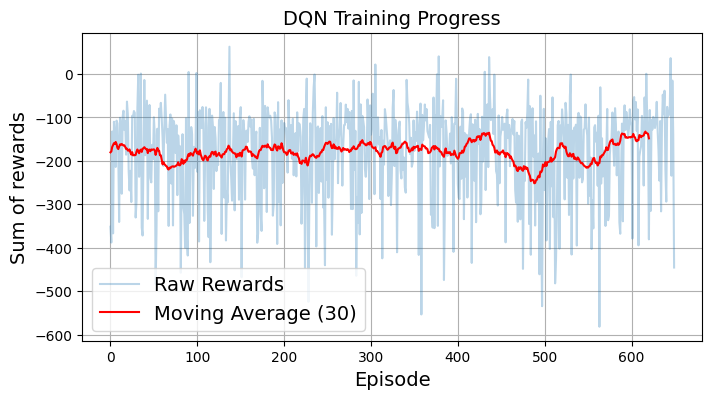

In [ ]:
# Define moving average function
def moving_average(values, window_size=30):
    return np.convolve(values, np.ones(window_size)/window_size, mode='valid')

# Generate reward plot with moving average
plt.figure(figsize=(8, 4))
plt.plot(rewardsD, label="Raw Rewards", alpha=0.3)  # Original noisy rewards
plt.plot(moving_average(rewardsD, window_size=30), label="Moving Average (30)", color="red")
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.legend()
plt.grid(True)
plt.title("DQN Training Progress")

# Show plot

Ther is evidence of learning at parts but still instability.

## Reflect

In this task I attempted to land a ship on the moon in the smoothest way. Deep QN learning was used. A grid search found the best parameters as per suggestions from peers.

Very mild learning was seen. This problem likely needs further time to tune.

I found that 32 neurons is optimal.

Applying Double DQN with a target function greatly enhanced performance.


## Task 3

In [ ]:
print(f_)

In [6]:
import sys
assert sys.version_info >= (3, 7)

In [7]:
#install gym and Arcade Learning Environment (ALE)
!pip install ale_py
!pip install gym[atari,accept-rom-license]

INFO: pip is looking at multiple versions of gym[accept-rom-license,atari] to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.7/721.7 kB 16.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 32.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 68.1 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827697 sha256=4b36492106bc25214eb81980a6dfa0e59dece3212a49d93853c09d5af7b0ec37
  Stored in directory: /root/.cache/pip/wheels/1c/77/9e/9af5470201a0b0543937933ee99ba884cd237d2faefe8f4d37
  Created wheel for AutoROM.accept-rom-license: filename=autorom_acc

In [8]:
# Imports
import gym
import numpy as np
import random
from collections import deque
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf

In [9]:
# Import Keras
IS_COLAB = "google.colab" in sys.modules
if IS_COLAB:
    os.environ["TF_USE_LEGACY_KERAS"] = "1"
    import tf_keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

In [10]:
# Breakout environment using the ALE/Breakout-v5 configuration from openAi gym
# render mode in rgb array to capture frames in rgb mode for visualisation
env = gym.make('ALE/Breakout-v5', render_mode='rgb_array')

# The ALE namespace doesn't have max steps set for Breakout, so we explicty set it to 27,000 steps, default for atari.
env.spec.max_episode_steps = 27000

# Print out some environment details
print(gym.envs.registry.keys())  # Overview over the flavors of environments that can be accessed through gym

print("Action Space:", env.action_space)
print("Observation Space:", env.observation_space)
print("Max Steps:", env.spec.max_episode_steps)
print("Reward Range:", env.reward_range)

# Set the state and action size
# state_size is the dimensions of the game's screen
# action_size is thee number actions available to the agent (Breakout offers [NOOP, FIRE, LEFT, RIGHT]
state_size = env.observation_space.shape
action_size = env.action_space.n

dict_keys(['ALE/Adventure-v5', 'ALE/Adventure-ram-v5', 'ALE/AirRaid-v5', 'ALE/AirRaid-ram-v5', 'ALE/Alien-v5', 'ALE/Alien-ram-v5', 'ALE/Amidar-v5', 'ALE/Amidar-ram-v5', 'ALE/Assault-v5', 'ALE/Assault-ram-v5', 'ALE/Asterix-v5', 'ALE/Asterix-ram-v5', 'ALE/Asteroids-v5', 'ALE/Asteroids-ram-v5', 'ALE/Atlantis-v5', 'ALE/Atlantis-ram-v5', 'ALE/Atlantis2-v5', 'ALE/Atlantis2-ram-v5', 'ALE/Backgammon-v5', 'ALE/Backgammon-ram-v5', 'ALE/BankHeist-v5', 'ALE/BankHeist-ram-v5', 'ALE/BasicMath-v5', 'ALE/BasicMath-ram-v5', 'ALE/BattleZone-v5', 'ALE/BattleZone-ram-v5', 'ALE/BeamRider-v5', 'ALE/BeamRider-ram-v5', 'ALE/Berzerk-v5', 'ALE/Berzerk-ram-v5', 'ALE/Blackjack-v5', 'ALE/Blackjack-ram-v5', 'ALE/Bowling-v5', 'ALE/Bowling-ram-v5', 'ALE/Boxing-v5', 'ALE/Boxing-ram-v5', 'ALE/Breakout-v5', 'ALE/Breakout-ram-v5', 'ALE/Carnival-v5', 'ALE/Carnival-ram-v5', 'ALE/Casino-v5', 'ALE/Casino-ram-v5', 'ALE/Centipede-v5', 'ALE/Centipede-ram-v5', 'ALE/ChopperCommand-v5', 'ALE/ChopperCommand-ram-v5', 'ALE/CrazyClimb

In [11]:
def display_frame(state):
    """
    Metod to Visualise state of the Breakout environment from OpenAi Gym
    """
    #state = env.reset()  # Reset the environment to inital state
    if isinstance(state, tuple):
        state = state[0]
    # Plot state
    plt.imshow(state)
    plt.title("State of Breakout Environment")
    plt.axis('off')
    plt.show()

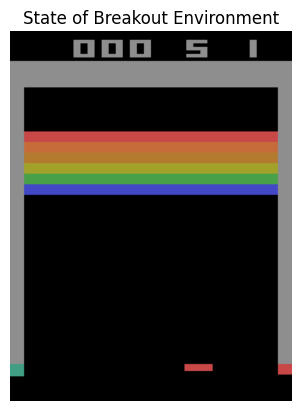

In [12]:
display_frame(env.reset())

/usr/local/lib/python3.11/dist-packages/gym/utils/passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


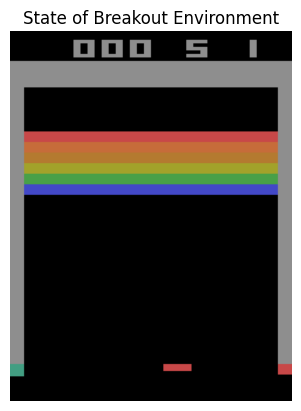

In [13]:
next_state, reward, done, _, _ = env.step(3)
display_frame(next_state)

We only really need grayscale

In [14]:
def preprocess1(im):
      temp = im[50:-12,6:-6]
      temp = tf.image.rgb_to_grayscale(temp)
      temp = tf.image.resize(temp, [110, 84], method = tf.image.ResizeMethod.NEAREST_NEIGHBOR)
      temp = tf.cast(temp, tf.float32)
      return temp[:,:,0] / 255.0

In [15]:
def preprocess2(im):
    im = im[31:195,:,:]  # Crop the height interval to [31:195], leaving the width unchanged
    im = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY) # Convert to grayscale image
    im = cv2.resize(im, (84, 84), interpolation=cv2.INTER_AREA) # Zoom to (84, 84)
    return im / 255.0  # Standardize to [0, 1]

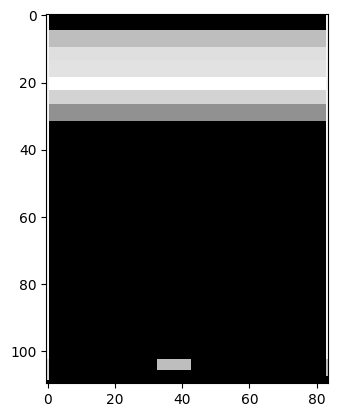

In [16]:
next_state, reward, done, _, _ = env.step(3)
processed_state = preprocess1(next_state)
#display_frame(processed_state)
plt.imshow(processed_state,cmap = 'gray')
plt.show()

In [17]:
def combine(im1, im2):
      if len(im1.shape) == 3 and im1.shape[0] == 4:  # checks if im1 already is a stack -->has 4 elements in the last dimension) that im2 can be appended to; dimesnions (batchsize = 1, height, width, stack size = 4) and im2 should be a single frame
        im2 = np.expand_dims(im2, 0)  # expand single frame im2 so that there is a batch size dimension
        im2 = np.expand_dims(im2, 3)  # expand single frame im2 so that there is a frame stack dimension -> necessary for appending
        im = np.append(im1[:,:,:,1:], im2, axis = 3) # im1[:, :, :, 1:] selects the three newest frames in the stack and appends im2 to it as the fourth
        return im
      else:  # if the first parameter is a single frame (which is the case for the first frame ever passed), this copies this single frame to produce a frame stack -> we don't want this to happen if we got beyond the first frame, so that temporal information are actually contained in the frame stack
        im = np.stack([im1]*4, axis = 2)  # appends 4 copies of im1 together
        return tf.expand_dims(im, 0)  # adds batch size dimension


In [18]:
def act(state):
  #if np.random.rand() <= self.epsilon:
    return np.random.randint(action_size)
  #q_values = self.model.predict(state, verbose = 0)
  #return np.argmax(q_values[0])

(1, 110, 84, 4)


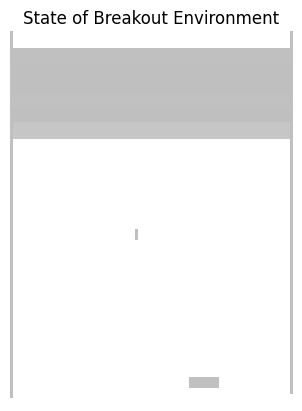

In [19]:
# example of using preprocess and combine to create stacked frames
# moce this into the training loop
# store stacked frames in replay buffer
# sample stacked frames from replay buffer
state, info = env.reset()
state = preprocess1(state)
action = act(state)
nextState, reward, done, _, _ = env.step(action)
nextState= preprocess2(nextState)
nextState = combine(nextState, state)

action = act(nextState)
state = nextState
nextState, reward, done, _, _ = env.step(action)
nextState= preprocess1(nextState)
nextState = combine(nextState, state)

print(nextState.get_shape())
display_frame(nextState[-0])


This is all we need, colours are somewhat irrelevant

Okay lets build the actual model

In [20]:
def build_model():
  model = Sequential()
  model.add(Conv2D(32, 8, (4,4), activation = 'relu', padding = 'valid', input_shape = state_size)) # TODO: maybe use elu
  model.add(Conv2D(64, 4, (2,2), activation = 'relu', padding = 'valid'))
  model.add(MaxPooling2D())
  model.add(Conv2D(64, 3, (1,1), activation = 'relu', padding = 'valid'))
  model.add(MaxPooling2D())
  model.add(Flatten())
  model.add(Dense(256, activation='relu'))
  model.add(Dense(action_size, activation='linear'))
  model.compile(optimizer=Adam(), loss=MeanSquaredError())
  model.summary()
  return model

In [21]:
model = build_model()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 51, 39, 32)          │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 18, 64)          │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 9, 64)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 10, 7, 64)           │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 3, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 960)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         246,016 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 322,980 (1.23 MB)

 Trainable params: 322,980 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
tf.random.set_seed(42)  # extra code – ensures reproducibility on the CPU upon each rerun
n_outputs = env.action_space.n  # Number of available actions

def epsilon_greedy_policy(state, epsilon=0):
    if np.random.rand() < epsilon:
        return np.random.randint(n_outputs)  # random action epsilon percent of the time
    else:
        Q_values = model.predict(state[np.newaxis], verbose=0)[0]
        return Q_values.argmax()  # optimal action according to the DQN


In [23]:
# extra code – A basic circular buffer implementation

from collections import deque

replay_buffer = deque(maxlen=2000)

def sample_experiences(batch_size):
    indices = np.random.randint(len(replay_buffer), size=batch_size)
    batch = [replay_buffer[index] for index in indices]
    return [
        np.array([experience[field_index] for experience in batch])
          for field_index in range(6)
    ]  # [states, actions, rewards, next_states, dones, truncateds]

In [24]:
# extra code – for reproducibility, and to generate the next figure
env.reset(seed=42)
np.random.seed(42)
tf.random.set_seed(42)
rewards = []
best_score = 0

In [25]:
batch_size = 64
discount_factor = 0.95
optimizer = tf.keras.optimizers.Nadam(learning_rate=5e-4)
loss_fn = tf.keras.losses.MeanSquaredError()

def training_step(batch_size):
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones, truncateds = experiences
    next_Q_values = model.predict(next_states, verbose=0)
    # next_Q_values = target_model.predict(next_states, verbose=0) # The target network predicts Q-values for next state
    max_next_Q_values = next_Q_values.max(axis=1) # Pick highest Q-value - greedy policy
    runs = 1.0 - (dones | truncateds)  # episode is not done or truncated
    runs = 1.0 - dones  # No need for truncateds
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values # Here target Q values are calculated using future rewards - Bellman equations.
    target_Q_values = target_Q_values.reshape(-1, 1)
    mask = tf.one_hot(actions, n_outputs)
    with tf.GradientTape() as tape:
        all_Q_values = model(states)
        Q_values = tf.reduce_sum(all_Q_values * mask, axis=1, keepdims=True)
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    grads = tape.gradient(loss, model.trainable_variables) # Here is where gradients are calculated
    optimizer.apply_gradients(zip(grads, model.trainable_variables)) # Here is where stochastic gradient descent is being performed using the gradients

In [26]:
def play_one_step(env, state, epsilon):
    action = epsilon_greedy_policy(state, epsilon)
    next_state, reward, done, truncated, info = env.step(action)
    replay_buffer.append((state, action, reward, next_state, done, truncated))
    return next_state, reward, done, truncated, info

In [ ]:
q_values_log = []

episode_count = 500

frames = []  # Store frames for animation

rewards = []

for episode in range(episode_count):
    obs, info = env.reset()
    total_reward=0
    # epsilon = 0.01 + (1.0 - 0.01) * np.exp(-episode / 600)
    epsilon = max(0.01, 1.0 - episode / (episode_count+100))
    # epsilon = 0.9
    for step in range(4000):
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        total_reward += reward  # Accumulate episode rewards

        # Capture frame for animation
        frame = env.render()
        frames.append(frame)

        if done or truncated:
            break
    # Store Q-values for analysis
    q_values = model.predict(obs[np.newaxis], verbose=0)[0]  # Get Q-values for current state
    q_values_log.append(q_values)

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, Reward: {total_reward}, eps: {epsilon:.3f}",
          end="")
    # rewards.append(step)
    rewards.append(total_reward)
    if total_reward >= best_score:
        best_weights = model.get_weights()
        best_score = total_reward
        print(f"\n New High Score: {best_score:.2f}")

    if episode > 30:
        training_step(batch_size)

    # if len(replay_buffer) > batch_size * 10:  # Ensure buffer has enough samples
    #       training_step(batch_size)

    # Update Target Network every 5 episodes
    # if episode % 50 == 0:
    #     target_model.set_weights(model.get_weights())

model.set_weights(best_weights)  # extra code – restores the best model weights

/usr/local/lib/python3.11/dist-packages/gym/utils/passive_env_checker.py:289: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


Episode: 1, Steps: 194, Reward: 1.0, eps: 1.000
 New High Score: 1.00
Episode: 2, Steps: 161, Reward: 1.0, eps: 0.998
 New High Score: 1.00
Episode: 3, Steps: 155, Reward: 1.0, eps: 0.997
 New High Score: 1.00
Episode: 4, Steps: 246, Reward: 3.0, eps: 0.995
 New High Score: 3.00
Episode: 5, Steps: 279, Reward: 3.0, eps: 0.993
 New High Score: 3.00
Episode: 22, Steps: 261, Reward: 3.0, eps: 0.965
 New High Score: 3.00
Episode: 34, Steps: 319, Reward: 5.0, eps: 0.945
 New High Score: 5.00
Episode: 106, Steps: 309, Reward: 5.0, eps: 0.825
 New High Score: 5.00
Episode: 112, Steps: 312, Reward: 5.0, eps: 0.815
 New High Score: 5.00
Episode: 152, Steps: 353, Reward: 8.0, eps: 0.748
 New High Score: 8.00
Episode: 323, Steps: 134, Reward: 0.0, eps: 0.463

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

def plot_animation(frames, skip=4, repeat=False, interval=40):

    frames = frames[::skip]  #  Skip frames to reduce load. -ease runtime

    fig, ax = plt.subplots()
    patch = ax.imshow(frames[0], cmap='gray', interpolation='none')
    ax.axis('off')

    def update_scene(num, frames, patch):
        patch.set_data(frames[num])
        return patch,

    anim = animation.FuncAnimation(
        fig, update_scene, fargs=(frames, patch),
        frames=len(frames), repeat=repeat, interval=interval)

    plt.close(fig)  #  Prevent duplicate frame display
    return HTML(anim.to_jshtml())  # Return HTML for Colab playback

In [ ]:
# Display animation in Google Colab
anim = plot_animation(frames, skip=8)
display(anim)  # This Works in Google Colab but takes about 2 mins to run(depending on how many frames you pull)

Looking at the animations it seems that the agent is not stopping the ball from leaving the environment allowed zone.

How can we improve this. increase reward for this action?

In [ ]:
# extra code – this cell generates and saves Figure 18–10
plt.figure(figsize=(8, 4))
plt.plot(rewards)
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.grid(True)
save_fig("dqn_ll_rewards_plot")
plt.show()

In [ ]:
# Define moving average function
def moving_average(values, window_size=50):
    return np.convolve(values, np.ones(window_size)/window_size, mode='valid')

# Generate reward plot with moving average
plt.figure(figsize=(8, 4))
plt.plot(rewards, label="Raw Rewards", alpha=0.3)  # Original noisy rewards
plt.plot(moving_average(rewards, window_size=50), label="Moving Average (50)", color="red")
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.legend()
plt.grid(True)
plt.title("DQN Training Progress")

# Show plot
plt.show()

No strong increase

In [ ]:
# Convert Q-values to NumPy array for plotting
q_values_log = np.array(q_values_log)

plt.figure(figsize=(10, 5))

# Plot Q-values for each action over episodes
for action in range(n_outputs):
    plt.plot(q_values_log[:, action], label=f"Q-value Action {action}")

plt.xlabel("Episode")
plt.ylabel("Q-Value")
plt.title("Q-Value Predictions Over Time")
plt.legend()
plt.grid()
plt.show()

## Now lets use double DQN

In [ ]:
@tf.function(reduce_retracing=True)
def training_step_double_dqn(batch_size):
    """Performs a single training step using Double DQN."""

    # Sample experiences from replay buffer
    experiences = sample_experiences(batch_size)
    states, actions, rewards, next_states, dones = experiences

    # Convert to TensorFlow tensors
    states = tf.convert_to_tensor(states, dtype=tf.float32)
    next_states = tf.convert_to_tensor(next_states, dtype=tf.float32)
    actions = tf.convert_to_tensor(actions, dtype=tf.int32)
    rewards = tf.convert_to_tensor(rewards, dtype=tf.float32)
    dones = tf.convert_to_tensor(dones, dtype=tf.float32)

    # Get Q-values from the online network
    next_Q_values_online = model(next_states, training=False)  # No .numpy() inside @tf.function
    best_next_actions = tf.argmax(next_Q_values_online, axis=1)

    # Get Q-values from the target network
    next_Q_values_target = target_model(next_states, training=False)
    max_next_Q_values = tf.gather(next_Q_values_target, best_next_actions, axis=1, batch_dims=1)

    # Compute target Q-values using Double DQN
    runs = 1.0 - dones
    target_Q_values = rewards + runs * discount_factor * max_next_Q_values
    target_Q_values = tf.reshape(target_Q_values, (-1, 1))  # Ensure correct shape

    # Compute loss and update model weights using SGD
    with tf.GradientTape() as tape:
        all_Q_values = model(states, training=False)  # Use training=False for inference
        Q_values = tf.gather(all_Q_values, actions, axis=1, batch_dims=1)
        Q_values = tf.reshape(Q_values, (-1, 1))

        # Compute loss
        loss = tf.reduce_mean(loss_fn(target_Q_values, Q_values))

    # Compute gradients and update weights
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return loss


In [ ]:
import itertools

# Define hyperparameter grid
epsilon_decays = [200, 500]  # Controls exploration-exploitation transition
batch_sizes = [64]  # Number of experiences per training step
discount_factors = [0.95, 0.99]  # Future reward discounting
learning_rates = [1e-3, 1e-4]  # Optimizer learning rates

# Store results
grid_results = []

# Iterate over all hyperparameter combinations
for epsilon_decay, batch_size, discount_factor, learning_rate in itertools.product(epsilon_decays, batch_sizes, discount_factors, learning_rates):
    print(f"\n🔍 Testing: epsilon_decay={epsilon_decay}, batch_size={batch_size}, discount_factor={discount_factor}, learning_rate={learning_rate}")

    # Reset environment, model, and variables
    q_values_log = []
    rewards = []
    frames = []
    best_score = -np.inf

    # Reinitialize optimizer with current learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    episode_count = 300  # Set episode count for grid search
    for episode in range(episode_count):
        obs, info = env.reset()
        total_reward = 0
        epsilon = max(0.01, 1.0 - episode / (episode_count + epsilon_decay))

        for step in range(4000):  # Training loop
            obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
            total_reward += reward

            # Capture frame for animation (reduce frequency to save memory)
            if episode % 10 == 0:
                frame = env.render()
                frames.append(frame)

            if done or truncated:
                break

        # Store Q-values and rewards
        q_values = model.predict(obs[np.newaxis], verbose=0)[0]
        q_values_log.append(q_values)
        rewards.append(total_reward)

        # Track best model weights
        if total_reward >= best_score:
            best_weights = model.get_weights()
            best_score = total_reward
            print(f"\n New High Score: {best_score:.2f}")

        # Train the model after 30 episodes
        if episode > 30:
            training_step_double_dqn(batch_size)

        # Update target network every 50 episodes
        if episode % 50 == 0:
            target_model.set_weights(model.get_weights())

    # Restore best model weights for this hyperparameter setting
    model.set_weights(best_weights)

    # Store results for this hyperparameter combination
    avg_reward = np.mean(rewards[-50:])  # Average reward over last 50 episodes
    grid_results.append((epsilon_decay, batch_size, discount_factor, learning_rate, avg_reward))

# Identify the best hyperparameter combination
best_params = max(grid_results, key=lambda x: x[4])
print(f"\n✅ Best Hyperparameters: epsilon_decay={best_params[0]}, batch_size={best_params[1]}, discount_factor={best_params[2]}, learning_rate={best_params[3]}, Avg Reward={best_params[4]:.2f}")



🔍 Testing: epsilon_decay=200, batch_size=64, discount_factor=0.95, learning_rate=0.001

 New High Score: 1.00

 New High Score: 1.00

 New High Score: 1.00

 New High Score: 1.00

 New High Score: 1.00

 New High Score: 3.00

 New High Score: 5.00

 New High Score: 5.00

 New High Score: 5.00

 New High Score: 5.00

 New High Score: 5.00

 New High Score: 6.00

 New High Score: 6.00

🔍 Testing: epsilon_decay=200, batch_size=64, discount_factor=0.95, learning_rate=0.0001

 New High Score: 1.00

 New High Score: 2.00

 New High Score: 4.00

 New High Score: 4.00

 New High Score: 4.00

 New High Score: 5.00

 New High Score: 5.00

 New High Score: 6.00


In [ ]:
# Define hyperparameter grid
epsilon_decays = 200  # Controls exploration-exploitation transition
batch_sizes = 64  # Number of experiences per training step
discount_factors =  0.99  # Future reward discounting
learning_rates =  1e-4  # Optimizer learning rates

q_values_log = []

episode_count = 300

frames = []  # Store frames for animation

rewards = []

for episode in range(episode_count):
    obs, info = env.reset()
    total_reward=0
    epsilon = max(0.01, 1.0 - episode / (episode_count+100))
    for step in range(4000):
        obs, reward, done, truncated, info = play_one_step(env, obs, epsilon)
        total_reward += reward  # Accumulate episode rewards

        # Capture frame for animation
        frame = env.render()
        frames.append(frame)

        if done or truncated:
            break
    # Store Q-values for analysis
    q_values = model.predict(obs[np.newaxis], verbose=0)[0]  # Get Q-values for current state
    q_values_log.append(q_values)

    # extra code – displays debug info, stores data for the next figure, and
    #              keeps track of the best model weights so far
    print(f"\rEpisode: {episode + 1}, Steps: {step + 1}, Reward: {total_reward}, eps: {epsilon:.3f}",
          end="")
    # rewards.append(step)
    rewards.append(total_reward)
    if total_reward >= best_score:
        best_weights = model.get_weights()
        best_score = total_reward
        print(f"\n New High Score: {best_score:.2f}")

    if episode > 30:
        training_step_double_dqn(batch_size)

    # if len(replay_buffer) > batch_size * 10:  # Ensure buffer has enough samples
    #       training_step(batch_size)

    # Update Target Network every 5 episodes
    if episode % 50 == 0:
        target_model.set_weights(model.get_weights())

model.set_weights(best_weights)  # extra code – restores the best model weights

In [ ]:
# Display animation in Google Colab
anim = plot_animation(frames, skip=8)
display(anim)

In [ ]:
# Define moving average function
def moving_average(values, window_size=50):
    return np.convolve(values, np.ones(window_size)/window_size, mode='valid')

# Generate reward plot with moving average
plt.figure(figsize=(8, 4))
plt.plot(rewards, label="Raw Rewards", alpha=0.3)  # Original noisy rewards
plt.plot(moving_average(rewards, window_size=50), label="Moving Average (50)", color="red")
plt.xlabel("Episode", fontsize=14)
plt.ylabel("Sum of rewards", fontsize=14)
plt.legend()
plt.grid(True)
plt.title("DQN Training Progress")

# Show plot
plt.show()

### Improvements that could be made

#### Double DQN
This method has been displayed and shown to increase stability.

#### Sampling different parts of game state
In RL consecutive states are highly correlated.

If the agent only learns from recent experiences it may striggle to generalise well.

Use disjoint game states to learn would help this.

This could be implemented by sampling chanuks of states stoed in the replay buffer.